In [69]:
import pandas as pd    
import json
import matplotlib.pyplot as plt
import sys
import os
import importlib
import subprocess

sys.path.append('../utils/')
from vllm_server import *
from notebook_utils import *
import vllm_server
import notebook_utils

importlib.reload(vllm_server)
importlib.reload(notebook_utils)


<module 'notebook_utils' from '/home/p316289/Desktop/work/dl-mig-contention-aware-system/experiments/notebooks/../utils/notebook_utils.py'>

In [57]:
EXP_RESULTS_PATH="../results/"
EXP_NAME="ram_bandwidth_stress_1v1"
EXP_CPU_OFFLOAD_FLAG="_cpuoffload-on" # _cpuoffload-off in case of unsetting cpu offloading
EXP_ARTIFACTS_TAR="artifacts.tar.gz"
EXP_METADATA="run_metadata.json"
EXP_METRICS="system_metrics.tar.gz"
EXP_PHASE= ["baseline", "wram_stress"]

In [58]:
# Work on Latest Exp, unless stated otherwise
EXP_PATH_PRE=EXP_RESULTS_PATH + EXP_NAME + EXP_CPU_OFFLOAD_FLAG

latest_exp_dir = get_latest_experiment_dir(EXP_RESULTS_PATH, EXP_PATH_PRE)

if latest_exp_dir:
    print(f"Latest experiment directory: {latest_exp_dir}")
else:
    print("No matching experiment directory found.")

Latest experiment directory: ../results/../results/ram_bandwidth_stress_1v1_cpuoffload-on_20260930T004307


In [59]:
# Print experiment metadata
with open(f"{latest_exp_dir}/{EXP_METADATA}", 'r') as f:
    metadata = json.load(f)
    print(json.dumps(metadata, indent=2))

{
  "cpu_offload_by_model": {
    "Qwen/Qwen2.5-1.5B-Instruct": "0.2",
    "Qwen/Qwen2.5-3B-Instruct-GPTQ-Int8": "0.2",
    "RedHatAI/SmolLM-1.7B-Instruct-quantized.w8a16": "0.2",
    "RedHatAI/gemma-2-2b-it-quantized.w4a16": "0.1"
  },
  "cpu_offload_enabled": true,
  "git_commit": "5a5af56774d98ed282998ee7776bb5468e854a99",
  "models": [
    "RedHatAI/gemma-2-2b-it-quantized.w4a16",
    "RedHatAI/SmolLM-1.7B-Instruct-quantized.w8a16",
    "Qwen/Qwen2.5-1.5B-Instruct",
    "Qwen/Qwen2.5-3B-Instruct-GPTQ-Int8"
  ],
  "request_count": [
    "200"
  ],
  "request_rate": [
    "10"
  ],
  "run_id": "ram_bandwidth_stress_1v1_cpuoffload-on_20260930T004307",
  "timestamp": "20260930T004307"
}


In [60]:
# Extract artifacts and system metrics
if not os.path.exists(f"/tmp/{str(latest_exp_dir).split('/')[-1]}"):
    os.mkdir(f"/tmp/{str(latest_exp_dir).split('/')[-1]}")

EXP_TMP=f"/tmp/{str(latest_exp_dir).split('/')[-1]}"
subprocess.run(["tar", "-xf", f"{latest_exp_dir}/{EXP_ARTIFACTS_TAR}", "-C", EXP_TMP])
subprocess.run(["tar", "-xf", f"{latest_exp_dir}/{EXP_METRICS}", "-C", EXP_TMP])

CompletedProcess(args=['tar', '-xf', '../results/../results/ram_bandwidth_stress_1v1_cpuoffload-on_20260930T004307/system_metrics.tar.gz', '-C', '/tmp/ram_bandwidth_stress_1v1_cpuoffload-on_20260930T004307'], returncode=0)

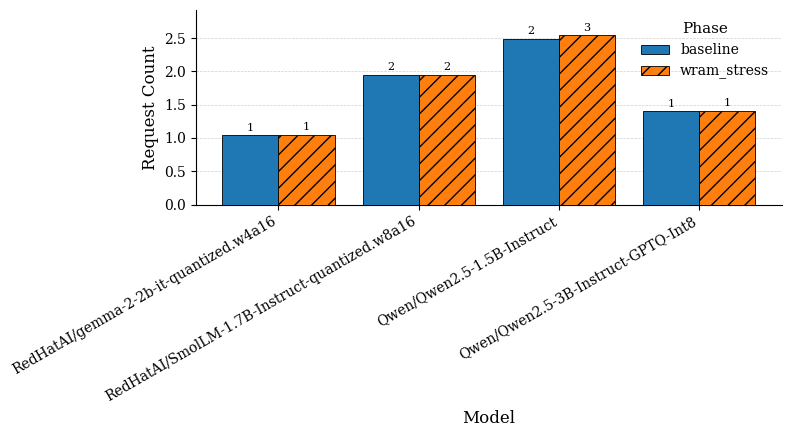

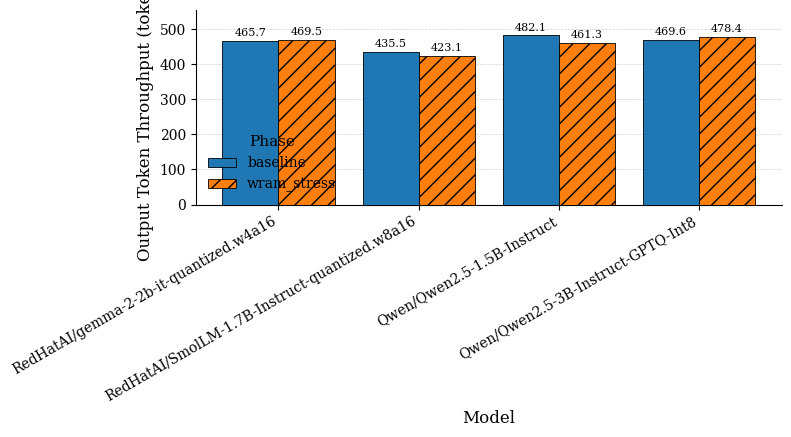

In [70]:
# Plot baseline vs stress performance
import numpy as np

results = []

for rps in metadata["request_rate"]:
    for n in metadata["request_count"]:
        for MODEL_NAME in metadata["models"]:
            for phase in EXP_PHASE:
                file = EXP_TMP + "/artifacts/" + f"{phase}/" + f"{MODEL_NAME.replace('/','_')}_rps{rps}_n{n}/" + f"{phase}.csv"
                df = read_summary_report(file)
                results.append({
                    "Model": MODEL_NAME,
                    "Mode": phase,
                    "Request Count": df.loc[df["Metric"] == "Request Throughput (requests/sec)", "Value"].item(),
                    "Output Token Throughput": (
                        df.loc[df["Metric"] == "Output Token Throughput (tokens/sec)", "Value"].item()
                    ),
                    "rps": rps,
                    "n" : n
                })

results_df = pd.DataFrame(results)
plot_throughput_and_rps(metadata["models"], results_df, EXP_PHASE)